<div align='center'>
<h1>Analisis Perbandingan Fuzzy Mamdani dan Sugeno</h1>
<h3>dalam Prediksi Tingkat Burnout Karyawan</h3>
<br>
<b>Dataset:</b> <a href='https://www.kaggle.com/datasets/blurredmachine/are-your-employees-burning-out'>Are Your Employees Burning Out?</a>
</div>

##### Identitas Kelompok
##### Mata Kuliah : Dasar Kecerdasan Artificial
##### Anggota     :
#####   1. Della Oktavia (103012400260)
#####   2. Muhammad Rifky Alfajri 103012430036
#####   3. Naufal Edgina Apta Aisy 103012400294
##### Kelas       : IF-48-02

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import os

# path ke root folder project
sys.path.insert(0, os.path.abspath('..'))

from fuzzy.membership import (fuzzify_all, mf_output, get_mf_curves,
                               trapezoid, triangle, SUGENO_CONSTANTS)
from fuzzy.mamdani import (mamdani_predict, mamdani_batch, evaluate_rules,
                            aggregate, centroid, RULES, get_burnout_level)
from fuzzy.sugeno  import sugeno_predict, sugeno_batch, weighted_average

## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/train.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (22750, 9)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.6,0.29
6,fffe33003300340039003100,2008-01-02,Female,Service,No,3.0,6.0,7.9,0.62
7,fffe32003600320037003400,2008-10-31,Female,Service,Yes,2.0,4.0,4.4,0.33
8,fffe32003200300034003700,2008-12-27,Female,Service,No,3.0,6.0,NaN,0.56
9,fffe31003600320030003200,2008-03-09,Female,Product,No,3.0,6.0,NaN,0.67


In [3]:
# informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [4]:
# statistik deskriptif
df.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

In [5]:
# cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per kolom:
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

Total missing: 4622


In [6]:
# cek data duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")

Jumlah duplikat: 0


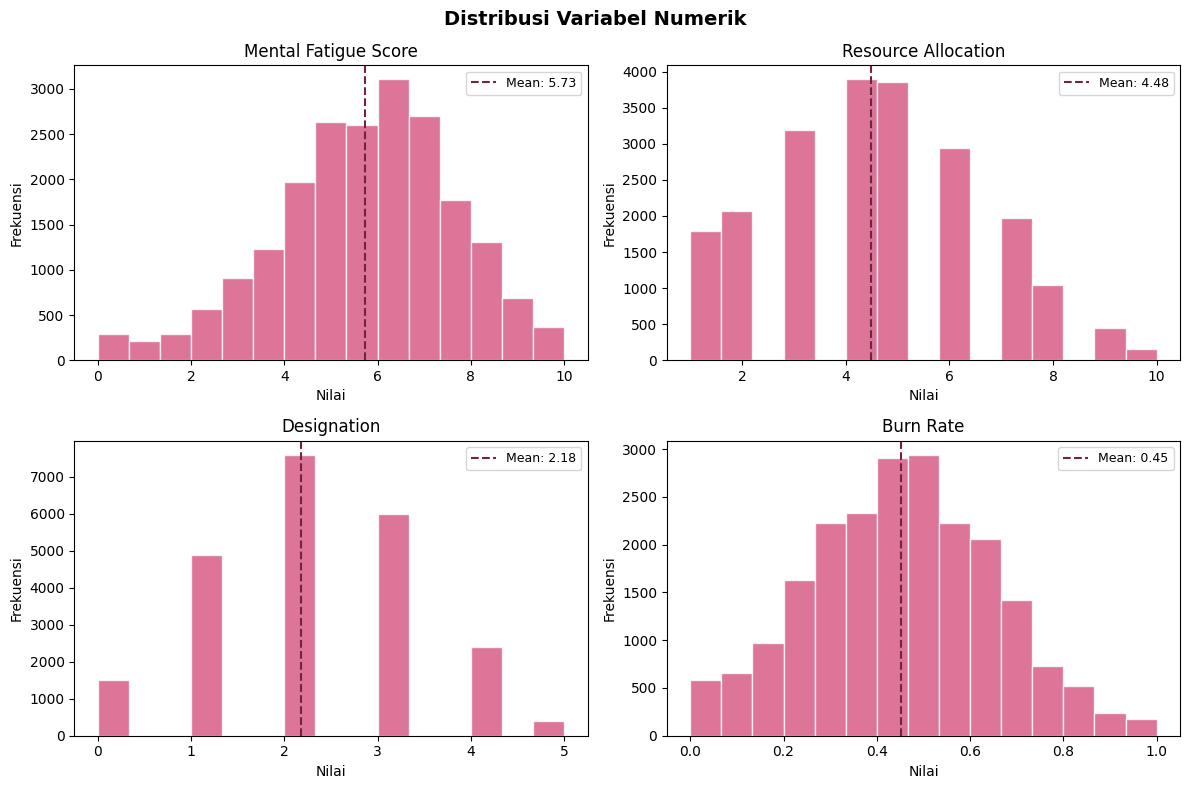

In [7]:
# distribusi kolom numerik — histogram
num_cols = ['Mental Fatigue Score', 'Resource Allocation', 'Designation', 'Burn Rate']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i // 2][i % 2]
    ax.hist(df[col].dropna(), bins=15, color='#D4537E', alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.axvline(df[col].mean(), color='#72243E', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

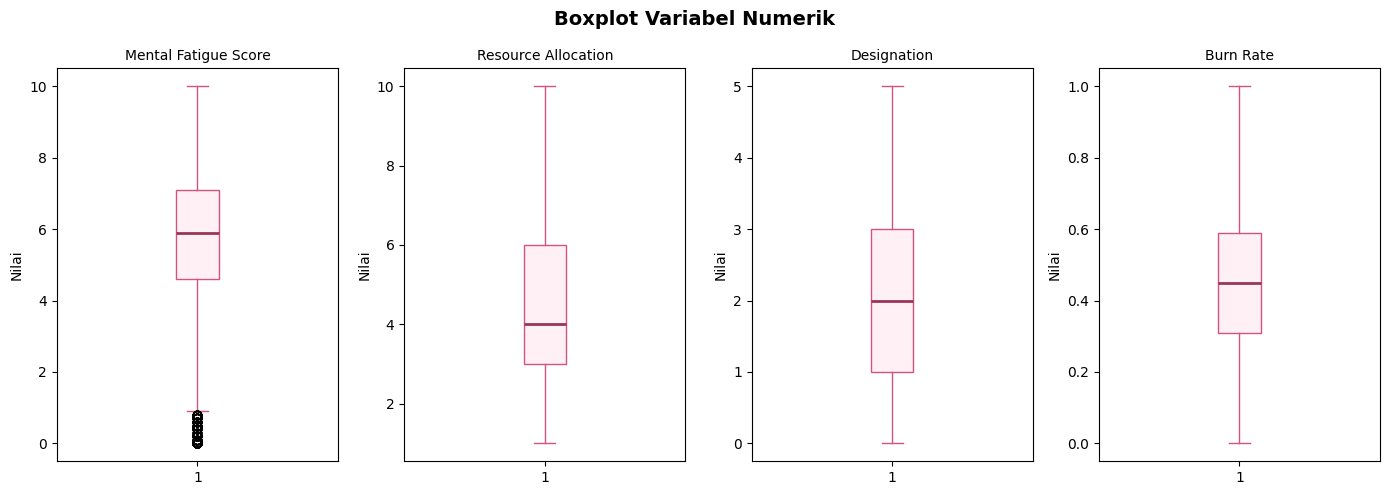

In [8]:
# boxplot untuk cek outlier
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Boxplot Variabel Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#FFF0F5', color='#D4537E'),
                    medianprops=dict(color='#993556', linewidth=2),
                    whiskerprops=dict(color='#D4537E'),
                    capprops=dict(color='#D4537E'),
                    flierprops=dict(marker='o', color='#D4537E', alpha=0.5))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

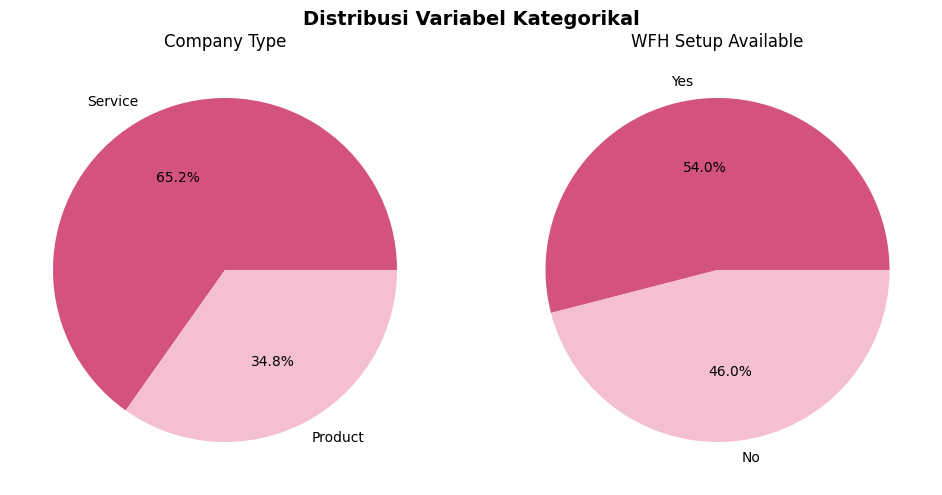

In [9]:
# distribusi kolom kategorikal — pie chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')

# Company Type
ct_counts = df['Company Type'].value_counts()
axes[0].pie(ct_counts.values, labels=ct_counts.index, autopct='%1.1f%%',
            colors=['#D4537E', '#F4C0D1'])
axes[0].set_title('Company Type')

# WFH Setup
wfh_counts = df['WFH Setup Available'].value_counts()
axes[1].pie(wfh_counts.values, labels=wfh_counts.index, autopct='%1.1f%%',
            colors=['#D4537E', '#F4C0D1'])
axes[1].set_title('WFH Setup Available')

plt.tight_layout()
plt.show()

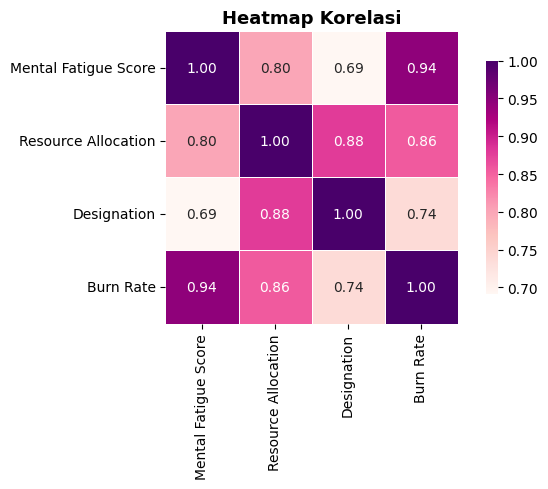

In [10]:
# heatmap korelasi variabel numerik
df_corr = df[['Mental Fatigue Score', 'Resource Allocation',
              'Designation', 'Burn Rate']].copy()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdPu',
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

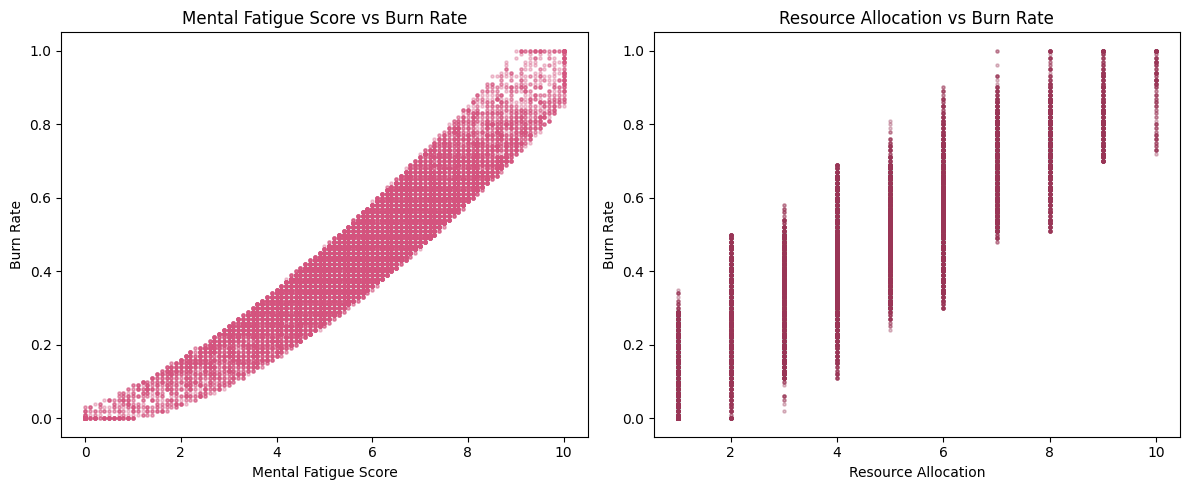

In [11]:
# scatter plot mental fatigue vs burn rate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Mental Fatigue Score'], df['Burn Rate'],
                alpha=0.3, color='#D4537E', s=5)
axes[0].set_xlabel('Mental Fatigue Score')
axes[0].set_ylabel('Burn Rate')
axes[0].set_title('Mental Fatigue Score vs Burn Rate')

axes[1].scatter(df['Resource Allocation'], df['Burn Rate'],
                alpha=0.3, color='#993556', s=5)
axes[1].set_xlabel('Resource Allocation')
axes[1].set_ylabel('Burn Rate')
axes[1].set_title('Resource Allocation vs Burn Rate')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [12]:
# hapus kolom tidak relevan
df_clean = df.copy()
df_clean = df_clean.drop(columns=['Employee ID', 'Date of Joining', 'Gender'], errors='ignore')

# encode variabel binary
df_clean['WFH_encoded']     = df_clean['WFH Setup Available'].map({'Yes': 1, 'No': 0})
df_clean['Company_encoded'] = df_clean['Company Type'].map({'Product': 1, 'Service': 0})

# imputasi median untuk nilai kosong
for col in ['Mental Fatigue Score', 'Resource Allocation', 'Burn Rate']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"Imputasi median pada: {col}")

print(f"\nShape setelah preprocessing: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Imputasi median pada: Mental Fatigue Score
Imputasi median pada: Resource Allocation
Imputasi median pada: Burn Rate

Shape setelah preprocessing: (22750, 8)
Missing values: 0


,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,WFH_encoded,Company_encoded
0,Service,No,2.0,3.0,3.8,0.16,0,0
1,Service,Yes,1.0,2.0,5.0,0.36,1,0
2,Product,Yes,2.0,4.0,5.8,0.49,1,1
3,Service,Yes,1.0,1.0,2.6,0.20,1,0
4,Service,No,3.0,7.0,6.9,0.52,0,0


## 5. Membership Function

Fungsi keanggotaan diimplementasikan from scratch tanpa library fuzzy.  
Menggunakan dua tipe fungsi: Trapezoid dan Triangle.

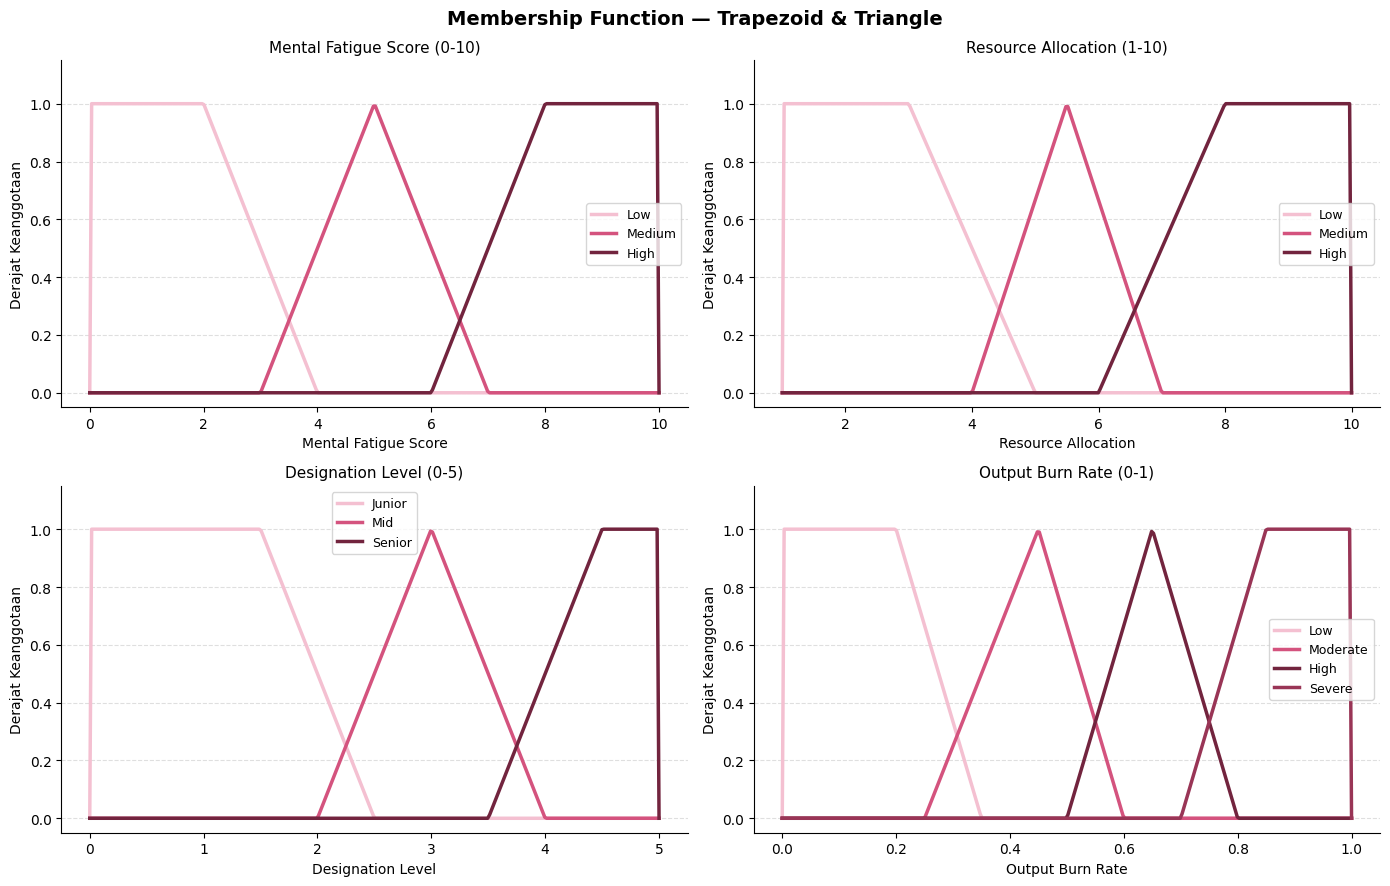

In [13]:
# visualisasi fungsi keanggotaan semua variabel
curves = get_mf_curves()

labels_map = {
    'fatigue':     (['LOW', 'MEDIUM', 'HIGH'],         'Mental Fatigue Score (0-10)'),
    'resource':    (['LOW', 'MEDIUM', 'HIGH'],         'Resource Allocation (1-10)'),
    'designation': (['JUNIOR', 'MID', 'SENIOR'],       'Designation Level (0-5)'),
    'output':      (['LOW', 'MODERATE', 'HIGH', 'SEVERE'], 'Output Burn Rate (0-1)'),
}

colors = ['#F4C0D1', '#D4537E', '#72243E', '#993556']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Membership Function — Trapezoid & Triangle', fontsize=14, fontweight='bold')

for idx, (key, (labels, title)) in enumerate(labels_map.items()):
    ax  = axes[idx // 2][idx % 2]
    cv  = curves[key]
    for i, lbl in enumerate(labels):
        ax.plot(cv['x'], cv[lbl], color=colors[i], linewidth=2.5, label=lbl.capitalize())
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(cv['xlabel'])
    ax.set_ylabel('Derajat Keanggotaan')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Rule Base (20 Rules)

In [14]:
# tampilkan semua rule
print(f"{'No':<4} {'Kondisi':<55} {'Output'}")
print("-" * 75)
for i, rule in enumerate(RULES):
    conds = ' AND '.join([f"{var}={lbl}" for var, lbl in rule['conditions']])
    print(f"{i+1:<4} {conds:<55} {rule['output']}")

No   Kondisi                                                 Output
---------------------------------------------------------------------------
1    fatigue=HIGH AND resource=HIGH                          SEVERE
2    fatigue=HIGH AND wfh=NO                                 SEVERE
3    desig=SENIOR AND fatigue=HIGH AND resource=HIGH         SEVERE
4    company=PRODUCT AND fatigue=HIGH AND resource=HIGH      SEVERE
5    fatigue=HIGH AND resource=MEDIUM                        HIGH
6    fatigue=MEDIUM AND resource=HIGH                        HIGH
7    wfh=NO AND resource=HIGH                                HIGH
8    desig=SENIOR AND resource=HIGH                          HIGH
9    desig=JUNIOR AND fatigue=HIGH                           HIGH
10   fatigue=MEDIUM AND wfh=NO AND resource=HIGH             HIGH
11   fatigue=MEDIUM AND resource=MEDIUM                      MODERATE
12   fatigue=HIGH AND resource=LOW                           MODERATE
13   desig=MID AND fatigue=MEDIUM               

## 7. Demo Fuzzifikasi

In [15]:
# contoh input karyawan
fatigue     = 7.0
resource    = 8.0
designation = 4.0
wfh         = 0      # 0 = No
company     = 1      # 1 = Product

fuzz = fuzzify_all(fatigue, resource, designation, wfh, company)

print("Hasil fuzzifikasi:")
print(f"  Mental Fatigue  : {fuzz['fatigue']}")
print(f"  Resource Alloc. : {fuzz['resource']}")
print(f"  Designation     : {fuzz['desig']}")
print(f"  WFH             : {fuzz['wfh']}")
print(f"  Company Type    : {fuzz['company']}")

Hasil fuzzifikasi:
  Mental Fatigue  : {'LOW': 0.0, 'MEDIUM': 0.0, 'HIGH': 0.5}
  Resource Alloc. : {'LOW': 0.0, 'MEDIUM': 0.0, 'HIGH': 1.0}
  Designation     : {'JUNIOR': 0.0, 'MID': 0.0, 'SENIOR': 0.5}
  WFH             : {'NO': 1.0, 'YES': 0.0}
  Company Type    : {'SERVICE': 0.0, 'PRODUCT': 1.0}


## 8. Fuzzy Mamdani

Alur: **Fuzzifikasi → Inferensi (AND=min, agregasi=max) → Defuzzifikasi (Centroid)**

In [16]:
result_m = mamdani_predict(fatigue, resource, designation, wfh, company)

print(f"Burn Rate  : {result_m['burn_rate']}")
print(f"Level      : {result_m['level']}")
print(f"Rule aktif : {len(result_m['fired_rules'])} dari 20")
print(f"Runtime    : {result_m['runtime']}s")
print()
print("Rule yang aktif:")
for r in result_m['fired_rules']:
    conds = ' AND '.join([f"{v}={l}" for v, l in r['conditions']])
    print(f"  Rule {r['rule_idx']:>2}: {conds} → {r['output']} (α={r['firing_strength']})")

Burn Rate  : 0.7506
Level      : SEVERE
Rule aktif : 6 dari 20
Runtime    : 0.0025s

Rule yang aktif:
  Rule  1: fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5)
  Rule  2: fatigue=HIGH AND wfh=NO → SEVERE (α=0.5)
  Rule  3: desig=SENIOR AND fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5)
  Rule  4: company=PRODUCT AND fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5)
  Rule  7: wfh=NO AND resource=HIGH → HIGH (α=1.0)
  Rule  8: desig=SENIOR AND resource=HIGH → HIGH (α=0.5)


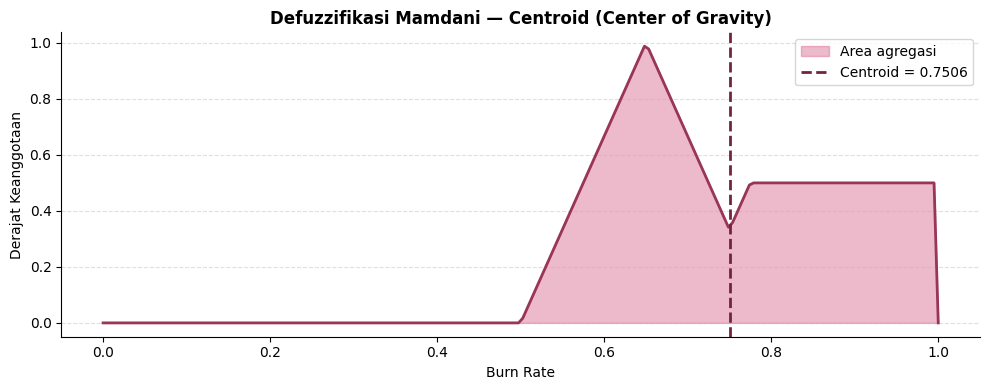

In [17]:
# visualisasi agregasi Mamdani
fig, ax = plt.subplots(figsize=(10, 4))

x_vals = result_m['x_values']
agg    = result_m['aggregated']

ax.fill_between(x_vals, agg, alpha=0.4, color='#D4537E', label='Area agregasi')
ax.plot(x_vals, agg, color='#993556', linewidth=2)
ax.axvline(result_m['burn_rate'], color='#72243E', linestyle='--', linewidth=2,
           label=f"Centroid = {result_m['burn_rate']}")
ax.set_title('Defuzzifikasi Mamdani — Centroid (Center of Gravity)', fontweight='bold')
ax.set_xlabel('Burn Rate')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Fuzzy Sugeno

Alur: **Fuzzifikasi → Inferensi (AND=min) → Defuzzifikasi (Weighted Average)**  
Output setiap rule adalah konstanta: LOW=0.15, MODERATE=0.42, HIGH=0.65, SEVERE=0.88

In [18]:
result_s = sugeno_predict(fatigue, resource, designation, wfh, company)

print(f"Burn Rate  : {result_s['burn_rate']}")
print(f"Level      : {result_s['level']}")
print(f"Rule aktif : {len(result_s['fired_rules'])} dari 20")
print(f"Runtime    : {result_s['runtime']}s")
print()
print("Rule yang aktif:")
for r in result_s['fired_rules']:
    conds = ' AND '.join([f"{v}={l}" for v, l in r['conditions']])
    print(f"  Rule {r['rule_idx']:>2}: {conds} → {r['output']} (α={r['firing_strength']}, z={r['output_value']})")

Burn Rate  : 0.7814
Level      : SEVERE
Rule aktif : 6 dari 20
Runtime    : 0.0001s

Rule yang aktif:
  Rule  1: fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5, z=0.88)
  Rule  2: fatigue=HIGH AND wfh=NO → SEVERE (α=0.5, z=0.88)
  Rule  3: desig=SENIOR AND fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5, z=0.88)
  Rule  4: company=PRODUCT AND fatigue=HIGH AND resource=HIGH → SEVERE (α=0.5, z=0.88)
  Rule  7: wfh=NO AND resource=HIGH → HIGH (α=1.0, z=0.65)
  Rule  8: desig=SENIOR AND resource=HIGH → HIGH (α=0.5, z=0.65)


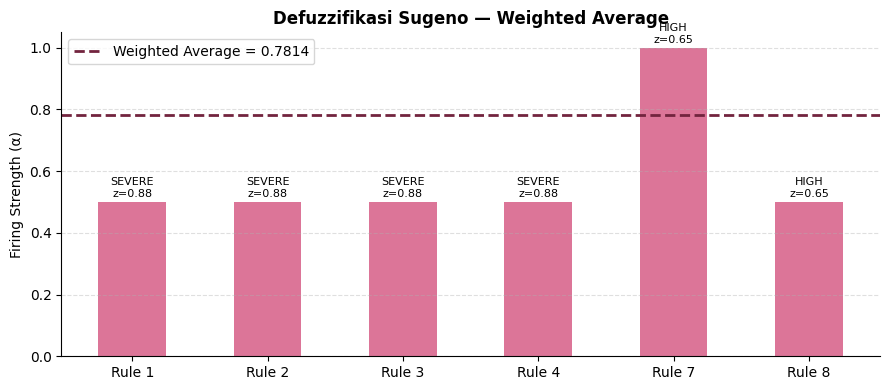

In [19]:
# visualisasi weighted average Sugeno
fired  = result_s['fired_rules']
labels = [r['output'] for r in fired]
alphas = [r['firing_strength'] for r in fired]
zvals  = [r['output_value'] for r in fired]

x_pos = range(len(fired))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(x_pos, alphas, color='#D4537E', alpha=0.8, width=0.5)
ax.axhline(result_s['burn_rate'], color='#72243E', linestyle='--', linewidth=2,
           label=f"Weighted Average = {result_s['burn_rate']}")

for bar, lbl, z in zip(bars, labels, zvals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{lbl}\nz={z}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"Rule {r['rule_idx']}" for r in fired])
ax.set_title('Defuzzifikasi Sugeno — Weighted Average', fontweight='bold')
ax.set_ylabel('Firing Strength (α)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Perbandingan Mamdani vs Sugeno

In [20]:
# perbandingan output pada contoh input yang sama
print("Perbandingan hasil pada input yang sama:")
print(f"  Input  : Fatigue={fatigue}, Resource={resource}, Designation={designation}, WFH={wfh}, Company={company}")
print()
print(f"  Mamdani : burn_rate={result_m['burn_rate']}, level={result_m['level']}, runtime={result_m['runtime']}s")
print(f"  Sugeno  : burn_rate={result_s['burn_rate']}, level={result_s['level']}, runtime={result_s['runtime']}s")
print(f"  Selisih : {abs(result_m['burn_rate'] - result_s['burn_rate']):.4f}")

Perbandingan hasil pada input yang sama:
  Input  : Fatigue=7.0, Resource=8.0, Designation=4.0, WFH=0, Company=1

  Mamdani : burn_rate=0.7506, level=SEVERE, runtime=0.0025s
  Sugeno  : burn_rate=0.7814, level=SEVERE, runtime=0.0001s
  Selisih : 0.0308


In [21]:
# uji beberapa kombinasi input berbeda
test_cases = [
    (2.0,  2.0, 1, 1, 0, 'Low input'),
    (5.0,  5.0, 3, 0, 1, 'Medium input'),
    (7.0,  8.0, 4, 0, 1, 'High input'),
    (9.5,  9.5, 5, 0, 0, 'Extreme input'),
]

print(f"{'Kasus':<15} {'Mamdani':>10} {'Sugeno':>10} {'Selisih':>10} {'Level M':>10}")
print("-" * 60)
for f, r, d, w, c, label in test_cases:
    m = mamdani_predict(f, r, d, w, c)
    s = sugeno_predict(f, r, d, w, c)
    print(f"{label:<15} {m['burn_rate']:>10.4f} {s['burn_rate']:>10.4f} "
          f"{abs(m['burn_rate']-s['burn_rate']):>10.4f} {m['level']:>10}")

Kasus              Mamdani     Sugeno    Selisih    Level M
------------------------------------------------------------
Low input           0.1422     0.1500     0.0078        LOW
Medium input        0.4333     0.4200     0.0133   MODERATE
High input          0.7506     0.7814     0.0308     SEVERE
Extreme input       0.7904     0.8033     0.0129     SEVERE


## 11. Evaluasi — MAE, MSE, RMSE

In [22]:
SAMPLE = 2000
print(f"Evaluasi pada {SAMPLE} data sampel acak dari {len(df_clean)} data...")
print()

t0 = time.time()
actual_m, pred_m = mamdani_batch(df_clean, sample_size=SAMPLE)
rt_m_batch = round(time.time() - t0, 2)

t0 = time.time()
actual_s, pred_s = sugeno_batch(df_clean, sample_size=SAMPLE)
rt_s_batch = round(time.time() - t0, 2)

mae_m  = round(float(np.mean(np.abs(actual_m - pred_m))), 4)
mse_m  = round(float(np.mean((actual_m - pred_m)**2)), 4)
rmse_m = round(float(np.sqrt(mse_m)), 4)

mae_s  = round(float(np.mean(np.abs(actual_s - pred_s))), 4)
mse_s  = round(float(np.mean((actual_s - pred_s)**2)), 4)
rmse_s = round(float(np.sqrt(mse_s)), 4)

print(f"{'Metrik':<12} {'Mamdani':>12} {'Sugeno':>12}")
print("-" * 38)
print(f"{'MAE':<12} {mae_m:>12.4f} {mae_s:>12.4f}")
print(f"{'MSE':<12} {mse_m:>12.4f} {mse_s:>12.4f}")
print(f"{'RMSE':<12} {rmse_m:>12.4f} {rmse_s:>12.4f}")
print(f"{'Runtime':<12} {rt_m_batch:>11.2f}s {rt_s_batch:>11.2f}s")

Evaluasi pada 2000 data sampel acak dari 22750 data...

Metrik            Mamdani       Sugeno
--------------------------------------
MAE                0.1324       0.1330
MSE                0.0273       0.0275
RMSE               0.1652       0.1658
Runtime             2.73s        0.26s


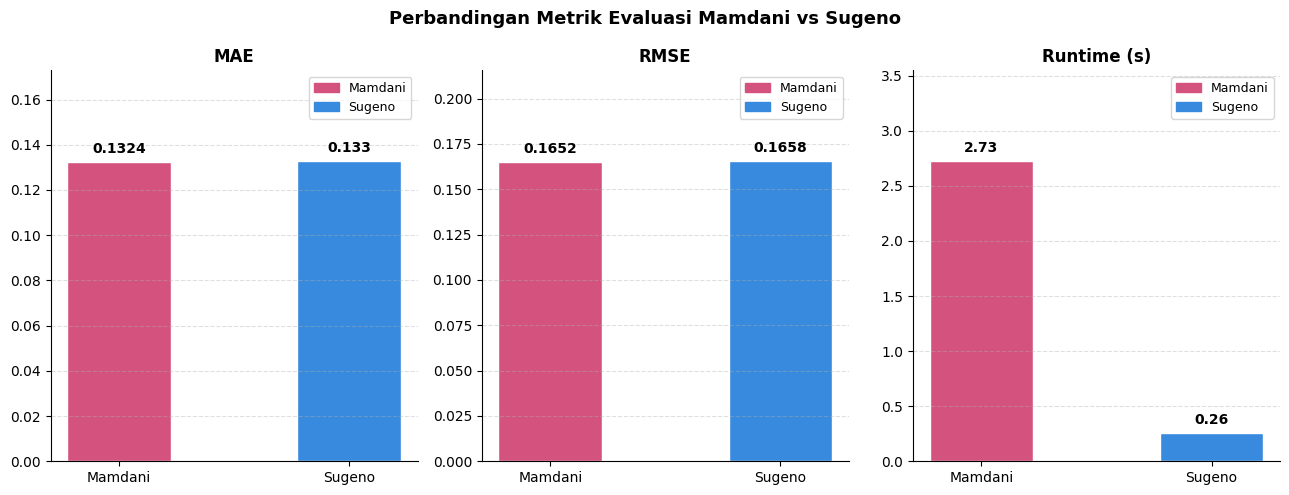

In [23]:
# visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Mamdani vs Sugeno', fontsize=13, fontweight='bold')

metrics = [('MAE', mae_m, mae_s), ('RMSE', rmse_m, rmse_s), ('Runtime (s)', rt_m_batch, rt_s_batch)]

for ax, (title, vm, vs) in zip(axes, metrics):
    bars = ax.bar(['Mamdani', 'Sugeno'], [vm, vs],
                  color=['#D4537E', '#378ADD'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, [vm, vs]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vm,vs)*0.02,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vm, vs) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='#D4537E', label='Mamdani'),
        plt.Rectangle((0,0),1,1, color='#378ADD', label='Sugeno')
    ], fontsize=9)

plt.tight_layout()
plt.show()

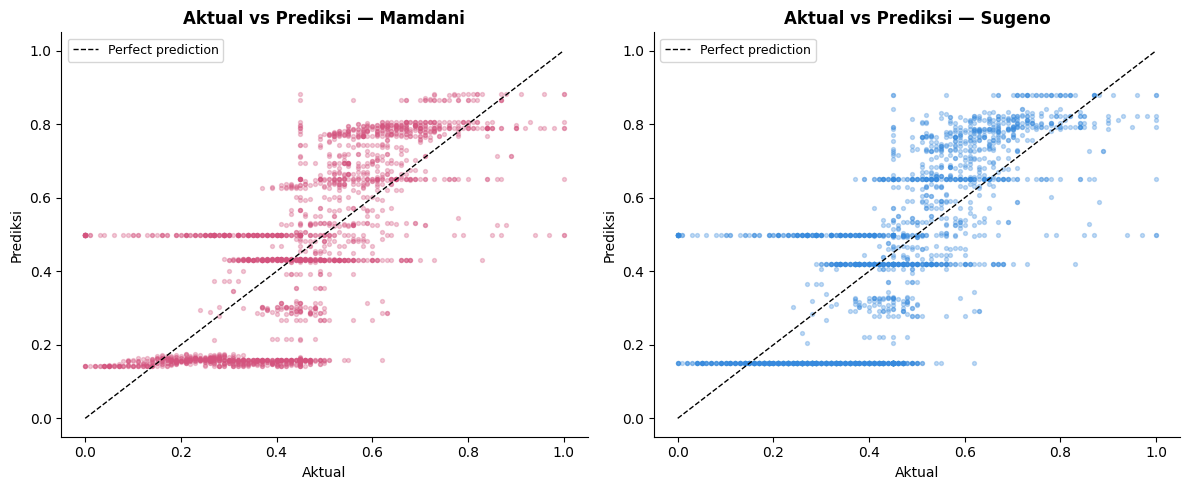

In [24]:
# scatter plot aktual vs prediksi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, actual, pred, label, clr in [
    (axes[0], actual_m, pred_m, 'Mamdani', '#D4537E'),
    (axes[1], actual_s, pred_s, 'Sugeno',  '#378ADD'),
]:
    ax.scatter(actual, pred, alpha=0.3, s=8, color=clr)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(f'Aktual vs Prediksi — {label}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 12. Integrasi Fuzzy

**Arsitektur:** Output fuzzy (Mamdani & Sugeno) dijadikan fitur tambahan untuk Random Forest.  
Fuzzy tidak digantikan ML, output fuzzy menjadi informasi tambahan yang memperkaya fitur.

In [25]:
from ml.random_forest import generate_fuzzy_features, train_and_evaluate

# generate fuzzy features (2000 sampel)
print("Generating fuzzy features...")
df_fuzz = generate_fuzzy_features(df_clean, sample_size=2000)
print(f"Selesai. Shape: {df_fuzz.shape}")
df_fuzz[['Mental Fatigue Score', 'Burn Rate', 'fuzzy_mamdani', 'fuzzy_sugeno']].head(10)

Generating fuzzy features...
Selesai. Shape: (2000, 10)


,Mental Fatigue Score,Burn Rate,fuzzy_mamdani,fuzzy_sugeno
11203,4.1,0.21,0.5000,0.5000
14049,5.9,0.46,0.4310,0.4200
13815,4.9,0.40,0.5000,0.5000
6603,5.0,0.41,0.5000,0.5000
4202,7.5,0.56,0.6500,0.6500
22543,7.6,0.56,0.7847,0.7436
9097,6.4,0.47,0.2902,0.3187
8165,7.6,0.60,0.7945,0.8103
13402,7.3,0.52,0.6688,0.6709
5259,3.0,0.16,0.1583,0.1500


In [26]:
# training dan evaluasi dua model
print("Training Random Forest...")
results = train_and_evaluate(df_fuzz)

print()
print(f"{'Model':<25} {'MAE':>8} {'MSE':>8} {'RMSE':>8} {'Runtime':>10}")
print("-" * 65)
for tag in ['rf_raw', 'rf_fuzzy']:
    r = results[tag]
    print(f"{r['label']:<25} {r['mae']:>8.4f} {r['mse']:>8.4f} {r['rmse']:>8.4f} {r['runtime']:>9.3f}s")

Training Random Forest...

Model                          MAE      MSE     RMSE    Runtime
-----------------------------------------------------------------
RF (tanpa fuzzy)            0.0614   0.0067   0.0821     0.239s
RF + Fuzzy Features         0.0593   0.0065   0.0808     0.211s


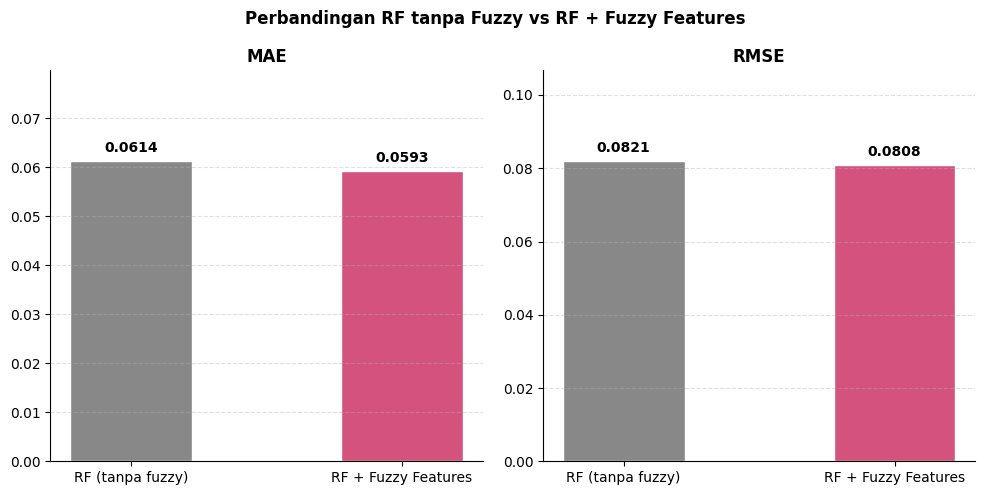

In [31]:
# visualisasi perbandingan RF
labels_rf = [results['rf_raw']['label'], results['rf_fuzzy']['label']]
mae_vals   = [results['rf_raw']['mae'],   results['rf_fuzzy']['mae']]
rmse_vals  = [results['rf_raw']['rmse'],  results['rf_fuzzy']['rmse']]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Perbandingan RF tanpa Fuzzy vs RF + Fuzzy Features', fontsize=12, fontweight='bold')

for ax, title, vals in [(axes[0],'MAE',mae_vals),(axes[1],'RMSE',rmse_vals)]:
    bars = ax.bar(labels_rf, vals, color=['#888888','#D4537E'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 13. Kesimpulan

In [27]:
print("=" * 60)
print("KESIMPULAN")
print("=" * 60)
print()
print("Perbandingan Mamdani vs Sugeno:")
print(f"  MAE            - Mamdani: {mae_m:.4f} | Sugeno: {mae_s:.4f}")
print(f"  MSE            - Mamdani: {mse_m:.4f} | Sugeno: {mse_s:.4f}")
print(f"  RMSE           - Mamdani: {rmse_m:.4f} | Sugeno: {rmse_s:.4f}")
print(f"  Runtime batch  - Mamdani: {rt_m_batch}s   | Sugeno: {rt_s_batch}s")
print()
print("Interpretasi:")
winner_acc = 'Mamdani' if mae_m <= mae_s else 'Sugeno'
winner_spd = 'Sugeno'  if rt_s_batch <= rt_m_batch else 'Mamdani'
speedup    = round(rt_m_batch / rt_s_batch, 1) if rt_s_batch > 0 else '-'
print(f"  - {winner_acc} menghasilkan akurasi lebih tinggi (MAE lebih rendah)")
print(f"  - {winner_spd} {speedup}x lebih cepat dari metode lainnya")
print()
print("Terdapat trade-off antara akurasi dan kecepatan komputasi.")
print("Untuk prediksi burnout yang mengutamakan presisi,")
print("Mamdani lebih direkomendasikan.")

KESIMPULAN

Perbandingan Mamdani vs Sugeno:
  MAE            - Mamdani: 0.1324 | Sugeno: 0.1330
  MSE            - Mamdani: 0.0273 | Sugeno: 0.0275
  RMSE           - Mamdani: 0.1652 | Sugeno: 0.1658
  Runtime batch  - Mamdani: 2.73s   | Sugeno: 0.26s

Interpretasi:
  - Mamdani menghasilkan akurasi lebih tinggi (MAE lebih rendah)
  - Sugeno 10.5x lebih cepat dari metode lainnya

Terdapat trade-off antara akurasi dan kecepatan komputasi.
Untuk prediksi burnout yang mengutamakan presisi,
Mamdani lebih direkomendasikan.
